<a href="https://colab.research.google.com/github/DangLeUyen/Computer-Vision-From-Scratch/blob/main/chestXray_VGG19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torchvision import datasets, transforms, models
import torch.nn as nn
import torch.optim as optim
import pathlib
from PIL import Image
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

In [21]:
def train_model(model, criterion, optimizer, train_loader, val_loader, epochs=10):

    res = {
        'train_accuracy': [],
        'val_accuracy': [],
        'train_loss': [],
        'val_loss': []
    }

    for epoch in range(epochs):
        model.train()
        train_correct = 0
        train_total = 0
        running_loss = 0.0

        print(f"\nEpoch {epoch + 1}/{epochs}")

        # -------- TRAINING --------
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            batch_correct = (preds == labels).sum().item()
            train_correct += batch_correct
            train_total += labels.size(0)

        train_acc = train_correct / train_total
        train_loss = running_loss / len(train_loader)

        print(f"Train Loss: {train_loss:.4f}, "
              f"Train Accuracy: {train_acc:.4f}")

        # -------- VALIDATION --------
        model.eval()
        val_correct = 0
        val_total = 0
        val_running_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        val_loss = val_running_loss / len(val_loader)

        print(f"Validation Loss: {val_loss:.4f}, "
              f"Validation Accuracy: {val_acc:.4f}")

        # -------- SAVE METRICS --------
        res['train_accuracy'].append(train_acc)
        res['val_accuracy'].append(val_acc)
        res['train_loss'].append(train_loss)
        res['val_loss'].append(val_loss)

    return res

def predict_test(model, test_loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return all_preds, all_labels

def plot_metrics(res):

    epochs = range(1, len(res['train_accuracy']) + 1)

    # ----- LOSS CURVE -----
    plt.figure()
    plt.plot(epochs, res['train_loss'], label='Training Loss')
    plt.plot(epochs, res['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # ----- ACCURACY CURVE -----
    plt.figure()
    plt.plot(epochs, res['train_accuracy'], label='Training Accuracy')
    plt.plot(epochs, res['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()



### Load dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [13]:
path = '/content/drive/MyDrive/Colab Notebooks/AUT/Dataset/chest_xray'
path = pathlib.Path(path)
# path

In [23]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 1
BATCH_SIZE = 128
NUM_EPOCHS = 100

data_transform = {
    "train": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "val": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

In [18]:
train_dataset = datasets.ImageFolder(path / "train", transform=data_transform['train'])
val_dataset = datasets.ImageFolder(path / "val", transform=data_transform['val'])
test_dataset = datasets.ImageFolder(path / "test", transform=data_transform['val'])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
num_classes = len(train_dataset.classes)

In [24]:
vgg_model = models.vgg19(pretrained=True)

# Freeze feature layers
for param in vgg_model.features.parameters():
  param.requires_grad = False

# Replace classifier
vgg_model.classifier = nn.Sequential(
    nn.Linear(512*7*7, 4096),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(4096, 4096),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(4096, num_classes)
)

# Freeze all classifier layers first
for param in vgg_model.classifier.parameters():
  param.requires_grad = False

# Only unfreeze the final classifier layer
for param in vgg_model.classifier[-1].parameters():
  param.requires_grad = True

vgg_model = vgg_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg_model.parameters(), lr=3e-4)

# Training
vgg_res = train_model(vgg_model, criterion, optimizer, train_loader, val_loader, epochs=NUM_EPOCHS)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Epoch 1/100
Train Loss: 0.4798, Train Accuracy: 0.7726
Validation Loss: 0.5256, Validation Accuracy: 0.8750

Epoch 2/100
Train Loss: 0.3205, Train Accuracy: 0.8957
Validation Loss: 0.4337, Validation Accuracy: 1.0000

Epoch 3/100
Train Loss: 0.2547, Train Accuracy: 0.9216
Validation Loss: 0.3791, Validation Accuracy: 1.0000

Epoch 4/100
Train Loss: 0.2296, Train Accuracy: 0.9229
Validation Loss: 0.3381, Validation Accuracy: 1.0000

Epoch 5/100
Train Loss: 0.2117, Train Accuracy: 0.9243
Validation Loss: 0.3239, Validation Accuracy: 0.9375

Epoch 6/100
Train Loss: 0.1961, Train Accuracy: 0.9277
Validation Loss: 0.3032, Validation Accuracy: 0.9375

Epoch 7/100
Train Loss: 0.1863, Train Accuracy: 0.9337
Validation Loss: 0.2614, Validation Accuracy: 1.0000

Epoch 8/100
Train Loss: 0.1826, Train Accuracy: 0.9340
Validation Loss: 0.2592, Validation Accuracy: 1.0000

Epoch 9/100
Train Loss: 0.1696, Train Accuracy: 0.9402
Validation Loss: 0.2488, Validation Accuracy: 1.0000

Epoch 10/100
Train

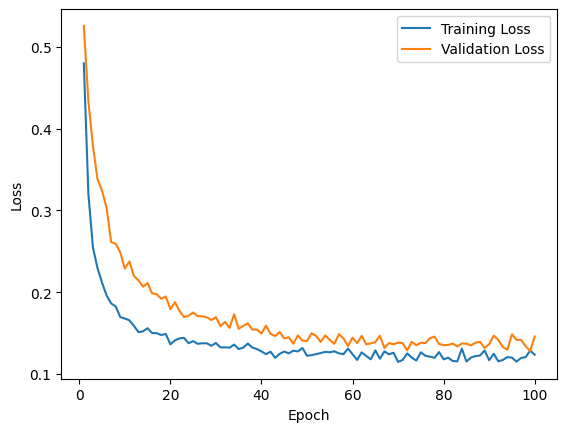

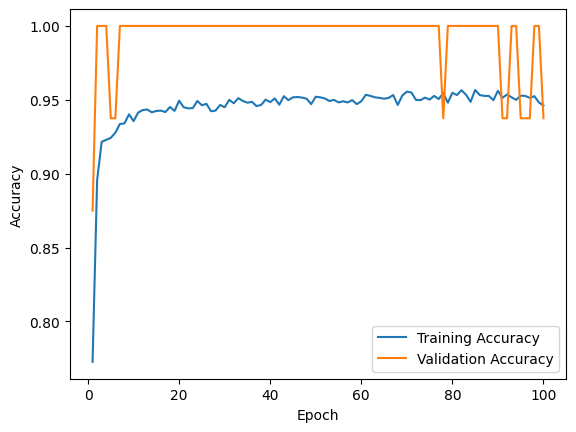

In [25]:
# Plot results
plot_metrics(vgg_res)

In [26]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

preds, labels = predict_test(vgg_model, test_loader, device)

acc = accuracy_score(labels, preds)
print("Test Accuracy:", acc)

print(classification_report(labels, preds))

Test Accuracy: 0.8125
              precision    recall  f1-score   support

           0       0.93      0.54      0.68       234
           1       0.78      0.98      0.87       390

    accuracy                           0.81       624
   macro avg       0.86      0.76      0.77       624
weighted avg       0.84      0.81      0.80       624

